In [1]:
import pandas as pd
import numpy as np

# We are going to be loading in our data from google drive in the form of a CSV into a PAndas DF

df_2018 = '1iDV_baPD_l0fbjYGH8dfXxqaPo6VVMr-'  


df_2019 = '1CNkIgoKJxRVnQ22D81C71YNEYzIS8eAO'

df_2020 = '1UotO0E_18tW3TBXqN6qNUns5JVcp1HdU'

df_2021 = '11-iXLiO6RhcKzOKdwx8q37h58-qwd1d6'

df_2022 = '1Jxzen5C854TfnIDgP1xZ6BZxTTwSZ3lM'  
direct_url_2018 =  f"https://docs.google.com/uc?id={df_2018}&export=download"
direct_url_2019 =  f"https://docs.google.com/uc?id={df_2019}&export=download"
direct_url_2020 =  f"https://docs.google.com/uc?id={df_2020}&export=download"
direct_url_2021 =  f"https://docs.google.com/uc?id={df_2021}&export=download"
direct_url_2022 = f"https://docs.google.com/uc?id={df_2022}&export=download"

# Read the CSV directly into a DataFrame 
# We are ging to be loading all o fhtem in seperate DFs, then we are going to concatenate them together.

# For some reason we only got 991 rows, even though we have 1000 rows in our Drive.
df_2018 = pd.read_csv(direct_url_2018)
df_2019 = pd.read_csv(direct_url_2019)
df_2020 = pd.read_csv(direct_url_2020)
df_2021 = pd.read_csv(direct_url_2021)
df_2022 = pd.read_csv(direct_url_2022)

In [2]:
full_df = pd.concat([df_2018, df_2019, df_2020, df_2021, df_2022])
full_df = full_df.drop(columns=['.geo', 'system:index'])

In [23]:
feat_cols = [
'2_B6','4_ndvi','5_B2',
'3_B6','3_B5','ndre_diff_may',
'2_vv_plus_vh','4_B3','3_evi',
'1_B12','ndre_diff_august','4_B12',
'3_vv_plus_vh','5_ndvi','3_VV',
'3_B3','5_et0_9_10','4_ndre',
'2_B11','2_B12','2_B5',
'5_ndwi','2_et0_6_7' ,'year', 'class', 'ndwi_diff_may'
]

In [24]:
df = full_df[feat_cols]

Training for Year: 2018...
[0]	validation_0-mlogloss:0.96122	validation_1-mlogloss:0.98327
[1]	validation_0-mlogloss:0.86479	validation_1-mlogloss:0.90297
[2]	validation_0-mlogloss:0.79660	validation_1-mlogloss:0.84847
[3]	validation_0-mlogloss:0.74398	validation_1-mlogloss:0.80892
[4]	validation_0-mlogloss:0.70037	validation_1-mlogloss:0.77643
[5]	validation_0-mlogloss:0.66728	validation_1-mlogloss:0.75476
[6]	validation_0-mlogloss:0.63888	validation_1-mlogloss:0.73543
[7]	validation_0-mlogloss:0.61331	validation_1-mlogloss:0.71936
[8]	validation_0-mlogloss:0.59293	validation_1-mlogloss:0.70643
[9]	validation_0-mlogloss:0.57274	validation_1-mlogloss:0.69515
[10]	validation_0-mlogloss:0.55522	validation_1-mlogloss:0.68347
[11]	validation_0-mlogloss:0.54124	validation_1-mlogloss:0.67718
[12]	validation_0-mlogloss:0.52772	validation_1-mlogloss:0.67100
[13]	validation_0-mlogloss:0.51746	validation_1-mlogloss:0.66624
[14]	validation_0-mlogloss:0.50541	validation_1-mlogloss:0.66043
[15]	val

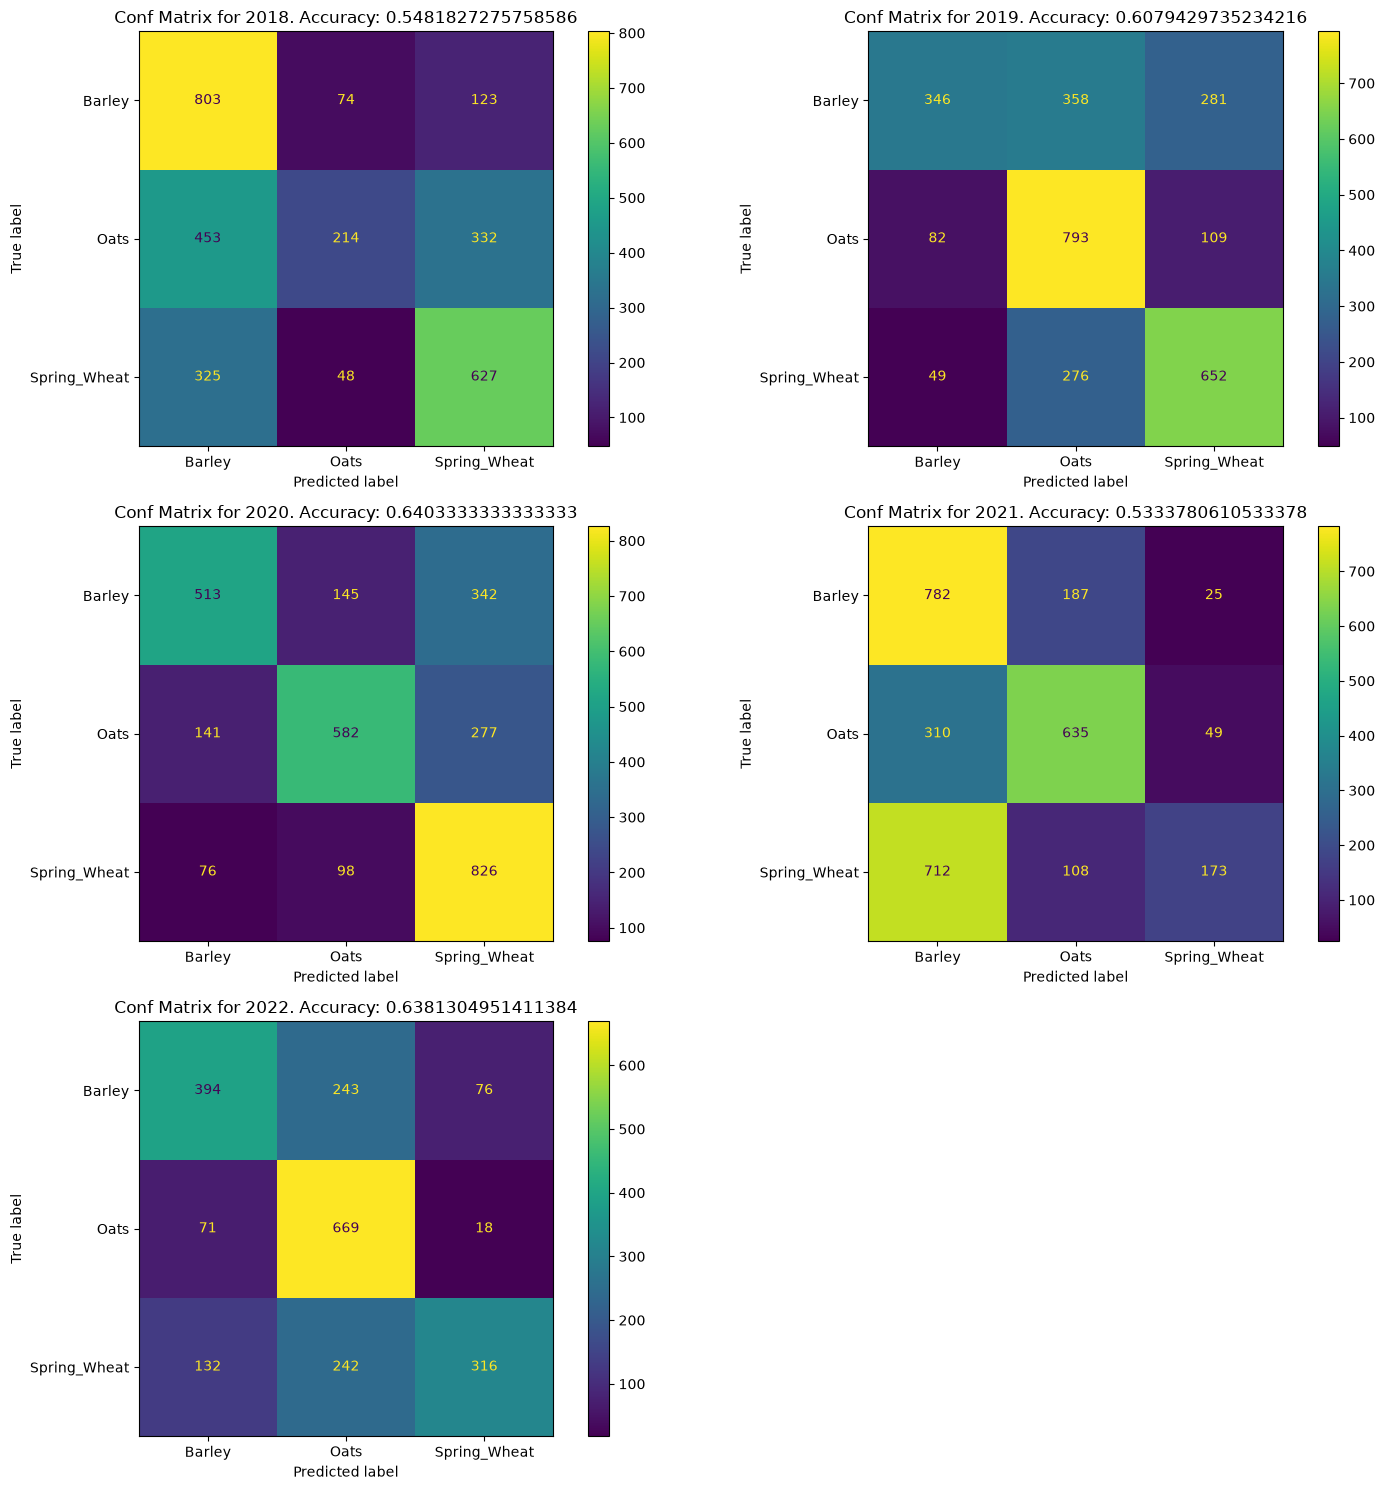

MEAN ACCURACY: 0.593593518125418
MEAN TRAIN ACCURACY: 0.9661918310861479


In [25]:
# Now we are going to train our XGB Model on these features
from functions import train_xgb_new

params = {
    'n_estimators': 100,
    'random_state': 42
}
xgb_importances, xgb_shap = train_xgb_new(params=params, full_df=df, num_features=23)

In [ ]:
# Now we are just going to hyperparm tune our XGB Model:
from functions import objective

